# Day 08：从块到网络 —— 堆叠残差块的艺术> 🌉 第八周 · ResNet 的深度 · 第 8 天前七天，我们从退化问题出发，理解了残差连接的直觉、代码、梯度原理和恒等映射。今天，我们要从"零件"走向"系统"——学习如何把单个残差块堆叠成完整的 ResNet 网络。这就像从"学会砌砖"到"盖一栋楼"的跨越。**今天的任务**：1. 理解 ResNet 的整体架构设计2. 处理"通道数变化"时的跳跃连接（1×1 卷积/投影）3. 用代码搭建一个完整的 ResNet 风格网络---

## 1. 历史剧场：ResNet 的架构设计哲学何恺明在设计 ResNet 时，遵循了一个核心哲学：> **简单、统一、可扩展**- **简单**：整个网络由同一种残差块重复堆叠而成- **统一**：每个残差块的结构完全相同- **可扩展**：通过增减残差块的数量，可以轻松调整网络深度这种设计哲学让 ResNet 极其灵活：ResNet-18、ResNet-34、ResNet-50、ResNet-101、ResNet-152——它们用的都是同一种残差块，只是数量不同。---

## 2. 生活隐喻：乐高积木ResNet 的架构就像乐高积木：- **基础积木**：残差块（ResidualBlock）——每一块都长得一样- **堆叠规则**：相同尺寸的积木堆在一起，形成一层- **过渡件**：当需要改变尺寸时，用一个"过渡块"连接不同层- **最终组装**：输入层 + 若干层积木 + 输出层 = 完整网络关键设计决策：1. **同一层内的所有残差块，输入输出尺寸相同**——这样跳跃连接可以直接相加2. **不同层之间用"过渡层"改变尺寸**——通道数加倍，空间尺寸减半3. **过渡层的跳跃连接需要"投影"**——用 1×1 卷积调整通道数---

<p align="center">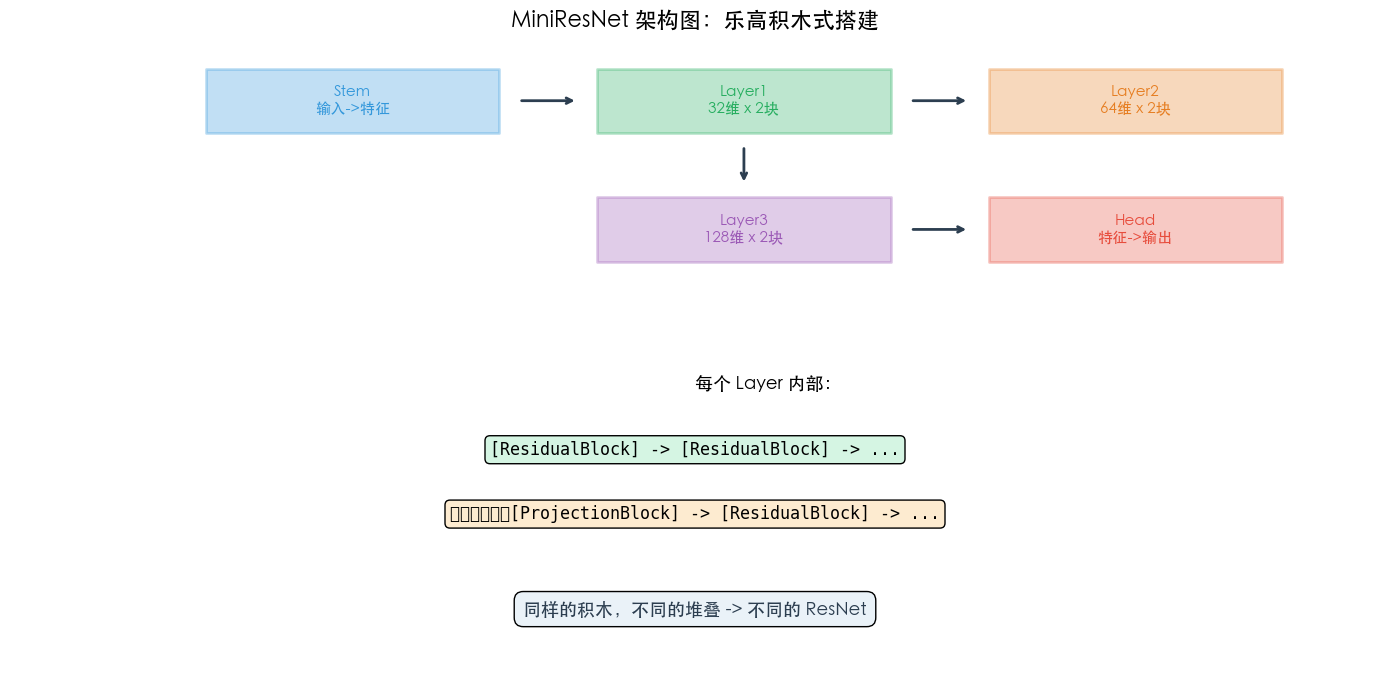</p>*MiniResNet 架构示意图*

## 3. 代码实验室：搭建完整 ResNet### 3.1 准备工作

In [ ]:
import torchimport torch.nn as nnimport torch.nn.functional as Fimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 3.2 基础残差块（全连接版本）为了教学清晰，我们先用全连接层而非卷积层来搭建。核心逻辑完全一致。

In [ ]:
class ResidualBlock(nn.Module):    """标准残差块：两层变换 + 跳跃连接"""    def __init__(self, hidden_size):        super().__init__()        self.layer1 = nn.Linear(hidden_size, hidden_size)        self.bn1 = nn.BatchNorm1d(hidden_size)        self.layer2 = nn.Linear(hidden_size, hidden_size)        self.bn2 = nn.BatchNorm1d(hidden_size)    def forward(self, x):        identity = x        out = self.layer1(x)        out = self.bn1(out)        out = F.relu(out)        out = self.layer2(out)        out = self.bn2(out)        out = out + identity        out = F.relu(out)        return out

### 3.3 处理通道数变化：投影残差块当网络需要改变特征维度时（比如从 64 维变成 128 维），跳跃连接不能直接相加了——因为维度不匹配！解决方案：在跳跃连接上加一个**投影层（Projection）**，把 x 的维度也变成目标维度。

In [ ]:
class ProjectionResidualBlock(nn.Module):    """带投影的残差块：当输入输出维度不同时使用"""    def __init__(self, in_size, out_size):        super().__init__()        self.layer1 = nn.Linear(in_size, out_size)        self.bn1 = nn.BatchNorm1d(out_size)        self.layer2 = nn.Linear(out_size, out_size)        self.bn2 = nn.BatchNorm1d(out_size)        self.projection = nn.Linear(in_size, out_size)    def forward(self, x):        identity = self.projection(x)        out = self.layer1(x)        out = self.bn1(out)        out = F.relu(out)        out = self.layer2(out)        out = self.bn2(out)        out = out + identity        out = F.relu(out)        return out

### 解读- `self.projection = nn.Linear(in_size, out_size)`：把 x 从 in_size 维投影到 out_size 维- `identity = self.projection(x)`：跳跃连接也跟着变维度- 这样 `out + identity` 的维度就匹配了---

## 4. 搭建完整网络：MiniResNet现在我们把所有零件组装起来，搭建一个完整的 MiniResNet：

In [ ]:
class MiniResNet(nn.Module):    """    迷你 ResNet：展示 ResNet 的核心架构设计    架构：    输入 → Stem(特征提取头) → Layer1(残差块组) → Layer2(残差块组) → ... → 输出    每一层由若干个相同尺寸的残差块堆叠而成    层与层之间通过 ProjectionResidualBlock 改变维度    """    def __init__(self, input_size=2, num_classes=1,                 layer_channels=[32, 64, 128],                 blocks_per_layer=[2, 2, 2]):        super().__init__()        self.stem = nn.Sequential(            nn.Linear(input_size, layer_channels[0]),            nn.BatchNorm1d(layer_channels[0]),            nn.ReLU(),        )        self.layers = nn.ModuleList()        in_channels = layer_channels[0]        for i, (out_channels, num_blocks) in enumerate(zip(layer_channels, blocks_per_layer)):            layer_blocks = []            if in_channels != out_channels:                layer_blocks.append(ProjectionResidualBlock(in_channels, out_channels))            else:                layer_blocks.append(ResidualBlock(in_channels))            for _ in range(num_blocks - 1):                layer_blocks.append(ResidualBlock(out_channels))            self.layers.append(nn.Sequential(*layer_blocks))            in_channels = out_channels        self.head = nn.Sequential(            nn.Linear(layer_channels[-1], num_classes),            nn.Sigmoid(),        )    def forward(self, x):        x = self.stem(x)        for layer in self.layers:            x = layer(x)        x = self.head(x)        return x

### 架构图解

输入 (2维)  ↓Stem: Linear(2→32) + BN + ReLU  ↓Layer1: [ResidualBlock(32)] × 2  ↓Layer2: [ProjectionBlock(32→64)] + [ResidualBlock(64)] × 1  ↓Layer3: [ProjectionBlock(64→128)] + [ResidualBlock(128)] × 1  ↓Head: Linear(128→1) + Sigmoid  ↓输出 (1维)

---

## 5. 训练与验证

In [ ]:
def make_moons_data(n_samples=500, noise=0.15):    np.random.seed(42)    n = n_samples // 2    theta_moon1 = np.linspace(0, np.pi, n)    theta_moon2 = np.linspace(0, np.pi, n)    x_moon1 = np.column_stack([np.cos(theta_moon1), np.sin(theta_moon1)]) + np.random.randn(n, 2) * noise    x_moon2 = np.column_stack([1 - np.cos(theta_moon2), 0.5 - np.sin(theta_moon2)]) + np.random.randn(n, 2) * noise    X = np.vstack([x_moon1, x_moon2]).astype(np.float32)    y = np.concatenate([np.zeros(n), np.ones(n)]).astype(np.float32)    return torch.tensor(X), torch.tensor(y).unsqueeze(1)X_data, y_data = make_moons_data()torch.manual_seed(42)mini_resnet = MiniResNet(    input_size=2,    num_classes=1,    layer_channels=[32, 64, 128],    blocks_per_layer=[3, 3, 3],)total_params = sum(p.numel() for p in mini_resnet.parameters())print(f"MiniResNet 参数量: {total_params:,}")print(f"\n网络结构:\n{mini_resnet}")

### 5.1 训练

In [ ]:
optimizer = torch.optim.Adam(mini_resnet.parameters(), lr=0.005)loss_fn = nn.BCELoss()losses = []accuracies = []epochs = 500for epoch in range(epochs):    predicted_probability = mini_resnet(X_data)    loss = loss_fn(predicted_probability, y_data)    accuracy = ((predicted_probability > 0.5).float() == y_data).float().mean()    optimizer.zero_grad()    loss.backward()    optimizer.step()    losses.append(loss.item())    accuracies.append(accuracy.item())    if (epoch + 1) % 100 == 0:        print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f} | Acc: {accuracy.item():.4f}")

### 5.2 结果可视化

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))axes[0].plot(losses, color='#3498db', alpha=0.8)axes[0].set_xlabel('Epoch', fontsize=12)axes[0].set_ylabel('Loss', fontsize=12)axes[0].set_title('MiniResNet 训练损失', fontsize=14)axes[0].grid(True, alpha=0.3)axes[1].plot(accuracies, color='#2ecc71', alpha=0.8)axes[1].set_xlabel('Epoch', fontsize=12)axes[1].set_ylabel('Accuracy', fontsize=12)axes[1].set_title('MiniResNet 训练准确率', fontsize=14)axes[1].grid(True, alpha=0.3)h = 0.02x_min, x_max = X_data[:, 0].min() - 0.5, X_data[:, 0].max() + 0.5y_min, y_max = X_data[:, 1].min() - 0.5, X_data[:, 1].max() + 0.5xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)Z = mini_resnet(grid).detach().numpy().reshape(xx.shape)axes[2].contourf(xx, yy, Z, alpha=0.3, levels=np.linspace(0, 1, 20), cmap='RdYlGn')axes[2].contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)for label, color, marker in [(0, '#e74c3c', 'x'), (1, '#2ecc71', 'o')]:    mask = y_data.squeeze() == label    axes[2].scatter(X_data[mask, 0], X_data[mask, 1], c=color, marker=marker, s=20, alpha=0.6)axes[2].set_title('MiniResNet 决策边界', fontsize=14)axes[2].set_aspect('equal')plt.tight_layout()plt.show()

---

## 6. 灵活扩展：调整深度和宽度MiniResNet 的设计让我们可以轻松调整网络的深度和宽度：

In [ ]:
configs = {    "MiniResNet-Small":  {"layer_channels": [16, 32],     "blocks_per_layer": [2, 2]},    "MiniResNet-Medium": {"layer_channels": [32, 64, 128], "blocks_per_layer": [3, 3, 3]},    "MiniResNet-Large":  {"layer_channels": [64, 128, 256, 512], "blocks_per_layer": [3, 4, 4, 3]},}for name, config in configs.items():    model = MiniResNet(input_size=2, num_classes=1, **config)    total_params = sum(p.numel() for p in model.parameters())    num_blocks = sum(config['blocks_per_layer'])    print(f"{name:20s} | {num_blocks} Blocks | {total_params:>8,} 参数")

### 解读- **Small**：4 个残差块，参数少，适合简单任务- **Medium**：9 个残差块，参数适中，适合中等任务- **Large**：14 个残差块，参数多，适合复杂任务这就是 ResNet 的可扩展性：**同一个架构，通过调整残差块数量，就能适应不同难度的任务。**---

## 今日结语今天我们学会了如何从单个残差块堆叠成完整的 ResNet 网络：1. **Stem（头）**：把原始输入转换到特征空间2. **Layer（层组）**：相同尺寸的残差块堆叠在一起3. **ProjectionBlock（投影块）**：维度变化时的过渡件4. **Head（尾）**：把特征映射到最终输出5. **可扩展性**：通过调整层数和通道数，轻松控制网络规模明天，我们将认识 ResNet 家族的全部成员——从 ResNet-18 到 ResNet-152。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 乐高积木——同样的块，不同的堆叠 | 残差块堆叠——同样的Block，不同的数量 || 过渡件——连接不同尺寸的积木 | 投影块——连接不同维度的特征 || 地基——把原始材料变成标准砖块 | Stem——把原始输入转换到特征空间 || 楼顶——最后封顶 | Head——把特征映射到最终输出 || 增加楼层 = 增加容量 | 增加残差块 = 增加网络深度 || 加宽楼层 = 增加空间 | 增加通道数 = 增加网络宽度 || 同一层的砖块尺寸相同 | 同一层的残差块维度相同 || 维度不匹配时需要"适配器" | 投影层（1×1卷积/线性层）调整维度 |